<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/Visualisation_spectre_Mira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Colab : Plot du spectre de omi Ceti (Mira)
### Instructions :
1. Télécharger le fichier FITS (ex: `_mira_20260221_820.fits`) dans Colab via l'icône 📁 à gauche.
2. Exécuter toutes les cellules dans l'ordre.
3. Adapter les paramètres dans la cellule 'Chargement du FITS' si nécessaire.

In [1]:
!pip install astropy matplotlib numpy scipy photutils -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.signal import find_peaks, medfilt
from google.colab import files  # <-- AJOUT POUR LE TÉLÉCHARGEMENT
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [3]:
# ⬇️ MODIFIEZ CES PARAMÈTRES ⬇️
filename = '_mira_20260221_820.fits'  # Remplacez par votre fichier
extension = 0  # Extension FITS (0, 1, ou 'PRIMARY')
wavelength_unit = 'angstrom'  # Votre fichier est en angstrom

# Chargement du FITS
with fits.open(filename) as hdul:
    data = hdul[extension].data
    header = hdul[extension].header

    # Extraction du spectre
    if data.ndim == 1:
        flux = data
    elif data.ndim == 2:
        flux = np.nanmean(data, axis=0)

    # Extraction de la calibration en longueur d'onde
    wcs = WCS(header)
    wavelengths = wcs.all_pix2world(np.arange(len(flux)), 0)[0]

    # Extraction de la date d'observation (DATE-OBS ou DATE)
    obs_date = header.get('DATE-OBS', header.get('DATE', 'Date inconnue'))
    print(f"Date d'observation : {obs_date}")

    print(f"✅ Fichier chargé : {filename}")
    print(f"   Plage spectrale : {wavelengths.min():.1f} - {wavelengths.max():.1f} {wavelength_unit}")

Date d'observation : 2026-02-21T19:40:19
✅ Fichier chargé : _mira_20260221_820.fits
   Plage spectrale : 3700.5 - 7580.0 angstrom


In [4]:
# Prétraitement
window_size = 3
smoothed_flux = np.convolve(flux, np.ones(window_size)/window_size, mode='same')
normalized_flux = (smoothed_flux - np.nanmin(smoothed_flux)) / (np.nanmax(smoothed_flux) - np.nanmin(smoothed_flux))
continuum = medfilt(normalized_flux, kernel_size=51)

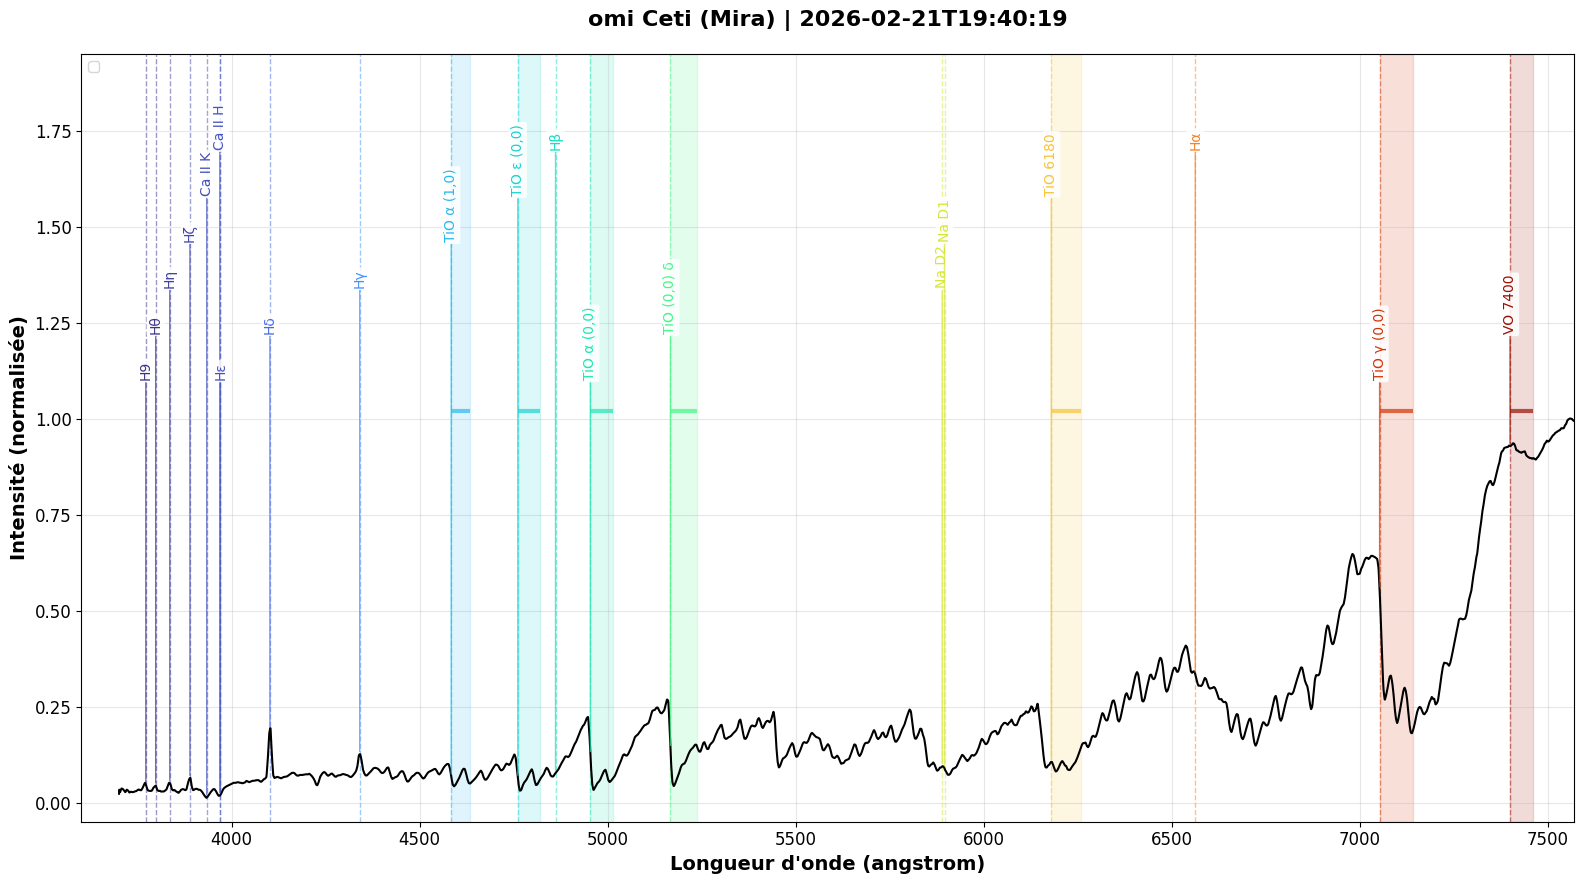

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import os
file_label = os.path.basename(filename)

# ⬇️ PARAMÈTRES ⬇️
wavelength_range = (3600, 7570)
wavelength_unit = 'angstrom'

# --- Raies atomiques (têtes de flèche fines) ---
atomic_lines = {
    'Hα': 6562.8,
    'Hβ': 4861.3,
    'Hγ': 4340.5,
    'Hδ': 4101.7,
    'Hε': 3970.1,
    'Hζ': 3889.0,
    'Hη': 3835.4,
    'Hθ': 3797.9,
    'H9': 3771.7,
    'Na D1': 5895.9,
    'Na D2': 5889.9,
    'Ca II H': 3968.5,
    'Ca II K': 3933.7,
}

# --- Bandes moléculaires TiO / VO ---
# tete = position de la tête de bande (bord le plus marqué)
# largeur = étendue approximative de la bande (Å), vers les lambda croissants
molecular_bands = {
    "TiO α (0,0)":  {'tete': 4954, 'largeur': 60},
    "TiO α (1,0)":  {'tete': 4584, 'largeur': 50},
    "TiO ε (0,0)":  {'tete': 4761, 'largeur': 60},
    "TiO (0,0) δ":  {'tete': 5167, 'largeur': 70},
    "TiO 6180":     {'tete': 6180, 'largeur': 80},
    "TiO γ (0,0)":  {'tete': 7053, 'largeur': 90},
    "TiO γ' (0,0)": {'tete': 7589, 'largeur': 90},
    "VO 7400":      {'tete': 7400, 'largeur': 60},
}

visible_atomic = {name: wl for name, wl in atomic_lines.items()
                  if wavelength_range[0] <= wl <= wavelength_range[1]}

visible_bands = {name: info for name, info in molecular_bands.items()
                 if wavelength_range[0] <= info['tete'] <= wavelength_range[1]}

# Tri par longueur d'onde pour gérer l'alternance des hauteurs d'annotation
all_items = ([(name, wl, 'atomic') for name, wl in visible_atomic.items()] +
              [(name, info['tete'], 'molecular') for name, info in visible_bands.items()])
all_items.sort(key=lambda x: x[1])

# Couleur = fonction de la longueur d'onde (palette 'turbo'), cohérente
# entre la tête de raie/bande, la zone ombrée et l'annotation
cmap = plt.cm.turbo
wl_min, wl_max = wavelength_range
def wl_to_color(wl):
    norm = (wl - wl_min) / (wl_max - wl_min)
    return cmap(np.clip(norm, 0, 1))

# Graphique
fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(wavelengths, normalized_flux, color='black', linewidth=1.5, label=file_label, zorder=2)

# Bandes moléculaires : zone ombrée + trait horizontal (étendue de la bande)
for name, info in visible_bands.items():
    color = wl_to_color(info['tete'])
    ax.axvspan(info['tete'], info['tete'] + info['largeur'],
               color=color, alpha=0.15, zorder=0)
    ax.hlines(y=1.02, xmin=info['tete'], xmax=info['tete'] + info['largeur'],
              color=color, linewidth=3, alpha=0.7, zorder=1)

# Annotation des raies (atomiques + têtes de bande moléculaires)
# - couleur = couleur de la longueur d'onde (palette turbo), cohérente avec
#   les têtes de raies/bandes ci-dessus
# - décalage alterné sur 6 niveaux pour éviter le chevauchement des flèches
#   (nécessaire avec la série de Balmer dense entre 3700 et 4000 Å)
# - flèches fines et verticales, placées dans une zone réservée au-dessus du spectre
y_levels = [1.10, 1.22, 1.34, 1.46, 1.58, 1.70]

for i, (name, wl, kind) in enumerate(all_items):
    color = wl_to_color(wl)
    idx = np.argmin(np.abs(wavelengths - wl))
    y_pos = normalized_flux[idx]
    y_text = y_levels[i % len(y_levels)]

    ax.axvline(x=wl, color=color, linestyle='--', alpha=0.5, linewidth=1, zorder=0)
    ax.annotate(
        name,
        xy=(wl, min(y_pos, 1.0)),
        xytext=(wl, y_text),
        arrowprops=dict(arrowstyle='-', color=color, lw=1, alpha=0.7,
                         shrinkA=0, shrinkB=2),
        ha='center',
        va='bottom',
        rotation=90,
        color=color,
        fontsize=10,
        zorder=3,
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.85, ec='none')
    )

# Configuration
ax.set_xlim(wavelength_range)
ax.set_ylim(-0.05, 1.95)
ax.set_xlabel(f'Longueur d\'onde ({wavelength_unit})', fontsize=14, fontweight='bold')
ax.set_ylabel('Intensité (normalisée)', fontsize=14, fontweight='bold')
ax.set_title(f'omi Ceti (Mira) | {obs_date}',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Sauvegarde et téléchargement
output_filename = filename.rsplit('.', 1)[0] + '.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
files.download(output_filename)